In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
def load_data(file_path):
    data = pd.read_csv(file_path)
    return data

In [15]:
def preprocess_data(data, corr_threshold=0.85):
    
#column drop
    correlation_matrix = data.corr(numeric_only=True)
    print("Correlation Matrix:\n", correlation_matrix)

    upper_tri = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    correlated_features = set()

    for col in upper_tri.columns:
        for row in upper_tri.index:
            if pd.notna(upper_tri.loc[row, col]) and abs(upper_tri.loc[row, col]) > corr_threshold:
                if data[row].var() > data[col].var():
                    correlated_features.add(col)
                else:
                    correlated_features.add(row)

    
    columns_to_drop = ['customer_id', 'last_purchase_date', 'preferred_payment', 'frequent_categories', 'avg_session_duration', 'cart_abandonment_rate']
    data = data.drop(columns=columns_to_drop + list(correlated_features), errors='ignore')


#encoding 
    categorical_columns = ['gender', 'location', 'income_bracket']
    for col in categorical_columns:
        if col in data.columns:
            unique_vals = data[col].unique()
            encoding = {val: idx for idx, val in enumerate(unique_vals)}
            data[col] = data[col].map(encoding)

    
#standardization
    numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
    for col in numerical_columns:
        mean = data[col].mean()
        std = data[col].std()
        if std != 0:  
            data[col] = (data[col] - mean) / std
        else:
            data[col] = 0 

    return data

In [16]:
# Elbow method to find the optimal number of clusters

def find_optimal_clusters(data, max_k=10):
    inertia = []
    X = data.to_numpy()
    for k in range(1, max_k + 1):
        centroids, labels = kmeans(X, k, max_iters=300)
        distances = np.linalg.norm(X - centroids[labels], axis=1)
        inertia.append(np.sum(distances**2))
    
    plt.plot(range(1, max_k + 1), inertia, marker='o')
    plt.title("Elbow Method to Determine Optimal Cluster") 
    plt.xlabel("Number of clusters")     
    plt.ylabel("Inertia")
    plt.show()

    ks = np.arange(1, max_k + 1)
    x_norm = (ks - ks.min()) / (ks.max() - ks.min())
    y_norm = (np.array(inertia) - np.min(inertia)) / (np.max(inertia) - np.min(inertia))

    
    line_vec = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
    line_vec /= np.linalg.norm(line_vec)
    point_vecs = np.vstack([x_norm - x_norm[0], y_norm - y_norm[0]]).T
    proj_lengths = np.dot(point_vecs, line_vec)
    proj_points = np.outer(proj_lengths, line_vec)
    distances_to_line = np.linalg.norm(point_vecs - proj_points, axis=1)

    optimal_k = np.argmax(distances_to_line) + 1 


    return optimal_k

In [17]:
# Custom K-means implementation
def kmeans(data, k, max_iters=300, tol=1e-4):
    n_samples, n_features = data.shape
    centroids = data[np.random.choice(n_samples, k, replace=False)]

    for _ in range(max_iters):
        distances = np.zeros((n_samples, k))
        for i in range(k):
            distances[:, i] = np.linalg.norm(data - centroids[i], axis=1)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([data[labels == i].mean(axis=0) for i in range(k)])

        if np.linalg.norm(new_centroids - centroids) < tol:
            break

        centroids = new_centroids

    return centroids, labels


Original Data Shape: (1000, 22)
Correlation Matrix:
                                age  total_purchases  avg_purchase_value  \
age                       1.000000        -0.000541           -0.045195   
total_purchases          -0.000541         1.000000           -0.022117   
avg_purchase_value       -0.045195        -0.022117            1.000000   
purchase_frequency        0.001048         0.016222           -0.024512   
premium_product_affinity  0.019835         0.015129           -0.018323   
brand_loyalty_score      -0.011876         0.038567            0.017528   
website_visits_30d       -0.009144         0.080943            0.019942   
avg_session_duration     -0.014698        -0.006347            0.004111   
cart_abandonment_rate     0.010224        -0.003819            0.001751   
email_engagement_rate     0.000428        -0.025340           -0.011710   
customer_lifetime_value  -0.015768         0.726649            0.570459   
churn_risk_score         -0.039135        -0.02

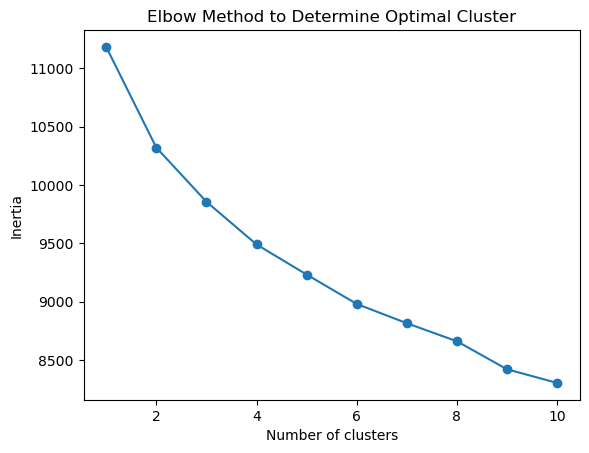

Segmented data saved to segmented_customers.csv


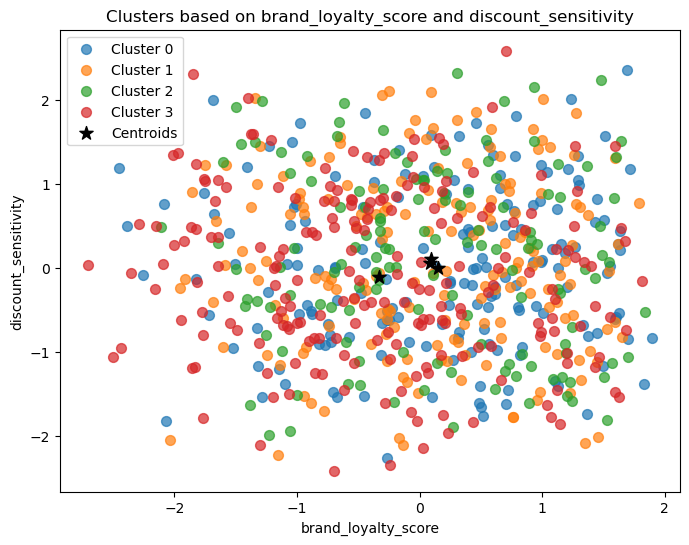

Cluster Characteristics:
              age    gender  location  income_bracket  total_purchases  \
Cluster                                                                  
0       -0.087762 -0.344308  0.707013       -0.321396        -0.456586   
1        0.445363  0.454248  0.094031        0.086383        -0.376812   
2       -0.139745 -0.098839  0.077499       -0.282104         1.212247   
3       -0.330423 -0.014063 -0.724043        0.279066        -0.145589   

         avg_purchase_value  purchase_frequency  premium_product_affinity  \
Cluster                                                                     
0                  0.033323           -0.376196                 -0.006990   
1                 -0.271446            0.757366                 -0.204179   
2                  0.855590            0.036552                  0.088582   
3                 -0.317382           -0.334401                  0.098122   

         brand_loyalty_score  website_visits_30d  email_engagement_

In [18]:
# Apply K-means clustering
def apply_kmeans(data, n_clusters):
    X = data.to_numpy()
    centroids, labels = kmeans(X, n_clusters)
    data = data.copy()
    data['Cluster'] = labels
    return data, centroids

# Visualize clusters
def visualize_clusters(data, centroids, x_col, y_col):
    plt.figure(figsize=(8, 6))
    for cluster in np.unique(data['Cluster']):
        cluster_data = data[data['Cluster'] == cluster]
        plt.scatter(cluster_data[x_col], cluster_data[y_col], label=f"Cluster {cluster}", s=50, alpha=0.7)
    plt.scatter(centroids[:, data.columns.get_loc(x_col)], centroids[:, data.columns.get_loc(y_col)], c='Black', marker='*', s=100, label='Centroids')
    plt.title(f"Clusters based on {x_col} and {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.show()

# Analyze clusters
def analyze_clusters(data):
    cluster_summary = data.groupby('Cluster').mean(numeric_only=True)
    print("Cluster Characteristics:")
    print(cluster_summary)
    return cluster_summary

# Split the dataset
def split_data(data):
    data = data.sample(frac=1, random_state=42).reset_index(drop=True)
    train_size = int(0.7 * len(data))
    val_size = int(0.15 * len(data))
    train_data = data[:train_size]
    val_data = data[train_size:train_size + val_size]
    test_data = data[train_size + val_size:]
    return train_data, val_data, test_data


# Main pipeline
def customer_segmentation_pipeline(file_path, output_path):

    data = load_data(file_path)
    print("Original Data Shape:", data.shape)

    data = preprocess_data(data)
    print("Preprocessed Data Shape:", data.shape)

    train_data, val_data, test_data = split_data(data)

    optimal_k = find_optimal_clusters(train_data, max_k=10)

    n_clusters = optimal_k

    clustered_data, centroids = apply_kmeans(train_data, n_clusters)

    clustered_data.to_csv(output_path, index=False)
    print(f"Segmented data saved to {output_path}")

    visualize_clusters(clustered_data, centroids, x_col='brand_loyalty_score', y_col='discount_sensitivity')

    cluster_summary = analyze_clusters(clustered_data)

customer_segmentation_pipeline("Customer_Segmentation_Data.csv", "segmented_customers.csv")